# Text Classification with Transformers (Encoder Part Only) from Scratch using Keras

## Importing Libraries

In [77]:
import keras
import numpy as np
import matplotlib.pyplot as plt

In [52]:
# checking keras backend
print(f"keras backend: {keras.backend.backend()}")
print(f"keras version: {keras.__version__}")

keras backend: tensorflow
keras version: 3.10.0


## Implementing Transformer block as layer

In [53]:
class TransformerBlock(keras.layers.Layer):

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):

        super().__init__()

        self.att = keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )

        self.ffn = keras.Sequential(
            [
                keras.layers.Dense(units=ff_dim, activation='relu'),
                keras.layers.Dense(units=embed_dim),
            ]
        )

        self.layernorm1 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = keras.layers.Dropout(rate=rate)
        self.dropout2 = keras.layers.Dropout(rate=rate)

    def call(self, inputs):

        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output)

        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)

        return self.layernorm2(out1 + ffn_output)

## Implementing Embedding layer with positional encoding

In [54]:
class TokenAndPositionEmbedding(keras.layers.Layer):

    def __init__(self, maxlen, vocab_size, embed_dim):

        super().__init__()

        self.token_emb = keras.layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim,
        )
        
        self.pos_emb = keras.layers.Embedding(
            input_dim=maxlen, output_dim=embed_dim
        )

    def call(self, x):

        maxlen = keras.ops.shape(x)[-1]
        positions = keras.ops.arange(start=0, stop=maxlen, step=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)

        return x + positions

## Loading and Preprocessing the IMDB Dataset

In [55]:
voacab_size=20000
maxlen=200

### Downloading the dataset

In [56]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=voacab_size)

In [57]:
X_train.shape

(25000,)

In [58]:
X_test.shape

(25000,)

In [59]:
y_train.shape

(25000,)

In [60]:
np.unique_counts(y_train)

UniqueCountsResult(values=array([0, 1]), counts=array([12500, 12500]))

In [61]:
y_train

array([1, 0, 0, ..., 0, 1, 0])

### Padding the sequences

In [62]:
X_train = keras.utils.pad_sequences(X_train, maxlen=maxlen)
X_test = keras.utils.pad_sequences(X_test, maxlen=maxlen)

## Model

### Defining model hyperparameters

In [63]:
# embedding size for each token
embed_dim = 32
# number of attention heads
num_heads = 2
# hidden layer size in feed forward network inside transformer
ff_dim = 32

### Input layer

In [64]:
inputs = keras.layers.Input(shape=(maxlen,))

### Embedding layer with positional encoding

In [65]:
embedding_layer = TokenAndPositionEmbedding(maxlen, voacab_size, embed_dim)
x = embedding_layer(inputs)

### Transformer block

In [66]:
transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
x = transformer_block(x)

### Pooling Layer

In [67]:
x = keras.layers.GlobalAveragePooling1D()(x)

### Dropout layer

In [68]:
x = keras.layers.Dropout(0.1)(x)

### FeedForward Neural Network Layer

In [69]:
x = keras.layers.Dense(units=20, activation='relu')(x)

### Dropout Layer

In [70]:
x = keras.layers.Dropout(0.1)(x)

### Output Layer

In [71]:
outputs = keras.layers.Dense(units=2, activation='softmax')(x)

### Creating the model

In [72]:
model = keras.Model(inputs=inputs, outputs=outputs)

### Model Summary

In [73]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_2  │ (None, 200, 32)        │       646,400 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 200, 32)        │        10,656 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 657,758 (2.51 MB)

 Trainable params: 657,758 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the model

In [74]:
model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

### Training the model

In [75]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.6993 - loss: 0.5261 - val_accuracy: 0.8801 - val_loss: 0.2840
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9310 - loss: 0.1879 - val_accuracy: 0.8694 - val_loss: 0.3408
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9628 - loss: 0.1139 - val_accuracy: 0.8612 - val_loss: 0.3691
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9796 - loss: 0.0664 - val_accuracy: 0.8433 - val_loss: 0.4772
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9867 - loss: 0.0475 - val_accuracy: 0.8474 - val_loss: 0.5401
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9902 - loss: 0.0317 - val_accuracy: 0.8344 - val_loss: 0.7231
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9921 - loss: 0.0256 - val_accuracy: 0.8339 - val_loss: 0.7957
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9927 - loss: 0.0218 - val_accuracy: 

### Visualizing training history

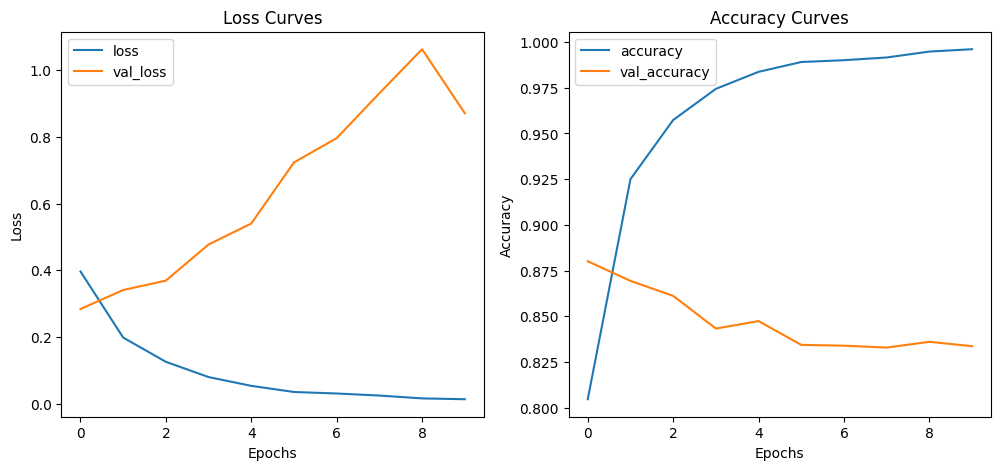

In [78]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
